Samantha Asefi (sma9am@virginia.edu)
DS 5001
8 May 2026

# Dendrograms - Similarity & Distance Measures

## imports

In [1]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re 
from numpy.linalg import norm
from scipy.spatial.distance import pdist
import seaborn as sns
sns.set(style="ticks")

%matplotlib inline

In [2]:
AUTHOR_MAP = {
    'luxemburg_reform-or-revolution':          'Rosa Luxemburg',
    'mao_on-guerrilla-warfare':                'Mao Zedong',
    'mao_correcting-mistaken-ideas':           'Mao Zedong',
    'mao_tactics-against-japanese-imperialism':'Mao Zedong',
    'mao_on-practice':                         'Mao Zedong',
    'mao_win-the-masses':                      'Mao Zedong',
    'marx_communist-manifesto':                'Karl Marx & Friedrich Engels',
    'marx_wage-labour-and-capital':            'Karl Marx',
    'fourier_selections':                      'Charles Fourier'
}

TITLE_MAP = {
    'luxemburg_reform-or-revolution':          'Reform or Revolution',
    'mao_on-guerrilla-warfare':                'On Guerrilla Warfare',
    'mao_correcting-mistaken-ideas':           'On Correcting Mistaken Ideas',
    'mao_tactics-against-japanese-imperialism':'On Tactics Against Japan',
    'mao_on-practice':                         'On Practice',
    'mao_win-the-masses':                      'Win the Masses',
    'marx_communist-manifesto':                'The Communist Manifesto',
    'marx_wage-labour-and-capital':            'Wage Labour and Capital',
    'fourier_selections':                      'Selections from his Writings'
}

In [3]:
OHCO  = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
OHCO_src = ['book_id', 'chap_num']


In [4]:
from pathlib import Path

f4_dir = Path('corpus/f4')
LIB   = pd.read_csv('corpus/f2/LIB.csv')
VOCAB = pd.read_csv(f4_dir / 'VOCAB.csv', index_col='term_str')
TFIDF = pd.read_csv(f4_dir / 'TFIDF.csv', index_col=OHCO_src)

In [5]:
L0 = TFIDF.astype('bool').astype('int')
L1 = TFIDF.apply(lambda x: x / x.sum() if x.sum() != 0 else x, axis=1)
L2 = TFIDF.apply(lambda x: x / norm(x) if norm(x) != 0 else x, axis=1)


In [6]:
DOC = TFIDF.reset_index()[OHCO_src].copy()
DOC.index.name = 'doc_id'

DOC['author'] = DOC.book_id.map(AUTHOR_MAP)
DOC['title']  = DOC.book_id.map(TITLE_MAP)

# Create a readable label: "Author — Title ch01"
DOC['label'] = (
    DOC['author'].str.split().str[-1]  # last name only
    + ' — '
    + DOC['title']
    + ' ch'
    + DOC['chap_num'].astype(int).astype(str).str.zfill(2)
)

print(DOC.shape)
DOC.head(10)


(63, 5)


/var/folders/c_/g3_6w_vn5vq7d8hqy9pb6tcm0000gn/T/ipykernel_35227/3790134255.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  DOC = TFIDF.reset_index()[OHCO_src].copy()


,book_id,chap_num,author,title,label
doc_id,,,,,
0,fourier_selections,1,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch01
1,fourier_selections,2,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch02
2,fourier_selections,3,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch03
3,fourier_selections,4,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch04
4,fourier_selections,5,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch05
5,fourier_selections,6,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch06
6,fourier_selections,7,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch07
7,fourier_selections,8,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch08
8,fourier_selections,9,Charles Fourier,Selections from his Writings,Fourier — Selections from his Writings ch09


In [7]:
PAIRS = pd.DataFrame(
    index=pd.MultiIndex.from_product([DOC.index.tolist(), DOC.index.tolist()])
).reset_index()
PAIRS = PAIRS[PAIRS.level_0 < PAIRS.level_1].set_index(['level_0', 'level_1'])
PAIRS.index.names = ['doc_a', 'doc_b']

print('Number of chapter pairs:', PAIRS.shape[0])

Number of chapter pairs: 1953


In [8]:
%time PAIRS['cosine']    = pdist(TFIDF, 'cosine')
%time PAIRS['euclidean'] = pdist(TFIDF, 'euclidean')
%time PAIRS['jaccard']   = pdist(L0, 'jaccard')
%time PAIRS['cityblock'] = pdist(TFIDF, 'cityblock')
%time PAIRS['js']        = pdist(L1, 'jensenshannon')

PAIRS.head()

CPU times: user 21.9 ms, sys: 538 μs, total: 22.5 ms
Wall time: 22.6 ms
CPU times: user 16.3 ms, sys: 311 μs, total: 16.6 ms
Wall time: 16.9 ms
CPU times: user 18.4 ms, sys: 458 μs, total: 18.8 ms
Wall time: 19 ms
CPU times: user 19.4 ms, sys: 201 μs, total: 19.6 ms
Wall time: 19.6 ms
CPU times: user 63.2 ms, sys: 173 μs, total: 63.3 ms
Wall time: 63.3 ms


cosine  euclidean   jaccard  cityblock        js
doc_a doc_b                                                    
0     1      0.880429   0.068185  0.892045   1.748307  0.767529
      2      0.934085   0.084718  0.932473   1.763020  0.792369
      3      0.839631   0.052883  0.871317   1.673161  0.759822
      4      0.762795   0.050441  0.855263   1.517683  0.741466
      5      0.978619   0.107664  0.968938   1.974162  0.816179

In [9]:
# Show the 20 most similar chapter pairs by cosine distance
top_pairs = PAIRS.sort_values('cosine').head(20).copy()
top_pairs['doc_a_label'] = top_pairs.index.get_level_values('doc_a').map(DOC['label'])
top_pairs['doc_b_label'] = top_pairs.index.get_level_values('doc_b').map(DOC['label'])
top_pairs[['doc_a_label', 'doc_b_label', 'cosine']].style.background_gradient('YlGn')


In [10]:
def hca(sims, title='', linkage_method='ward', color_thresh=0.3, figsize=(14, 16)):
    tree = sch.linkage(sims, method=linkage_method)
    labels = DOC.label.values
    
    fig, ax = plt.subplots(figsize=figsize)
    sch.dendrogram(
        tree,
        labels=labels,
        orientation='left',
        count_sort=True,
        distance_sort=True,
        above_threshold_color='.75',
        color_threshold=color_thresh,
        ax=ax
    )
    ax.set_title(title, fontsize=14, pad=12)
    plt.tick_params(axis='both', which='major', labelsize=9)
    plt.tight_layout()
    return fig


# COSINE

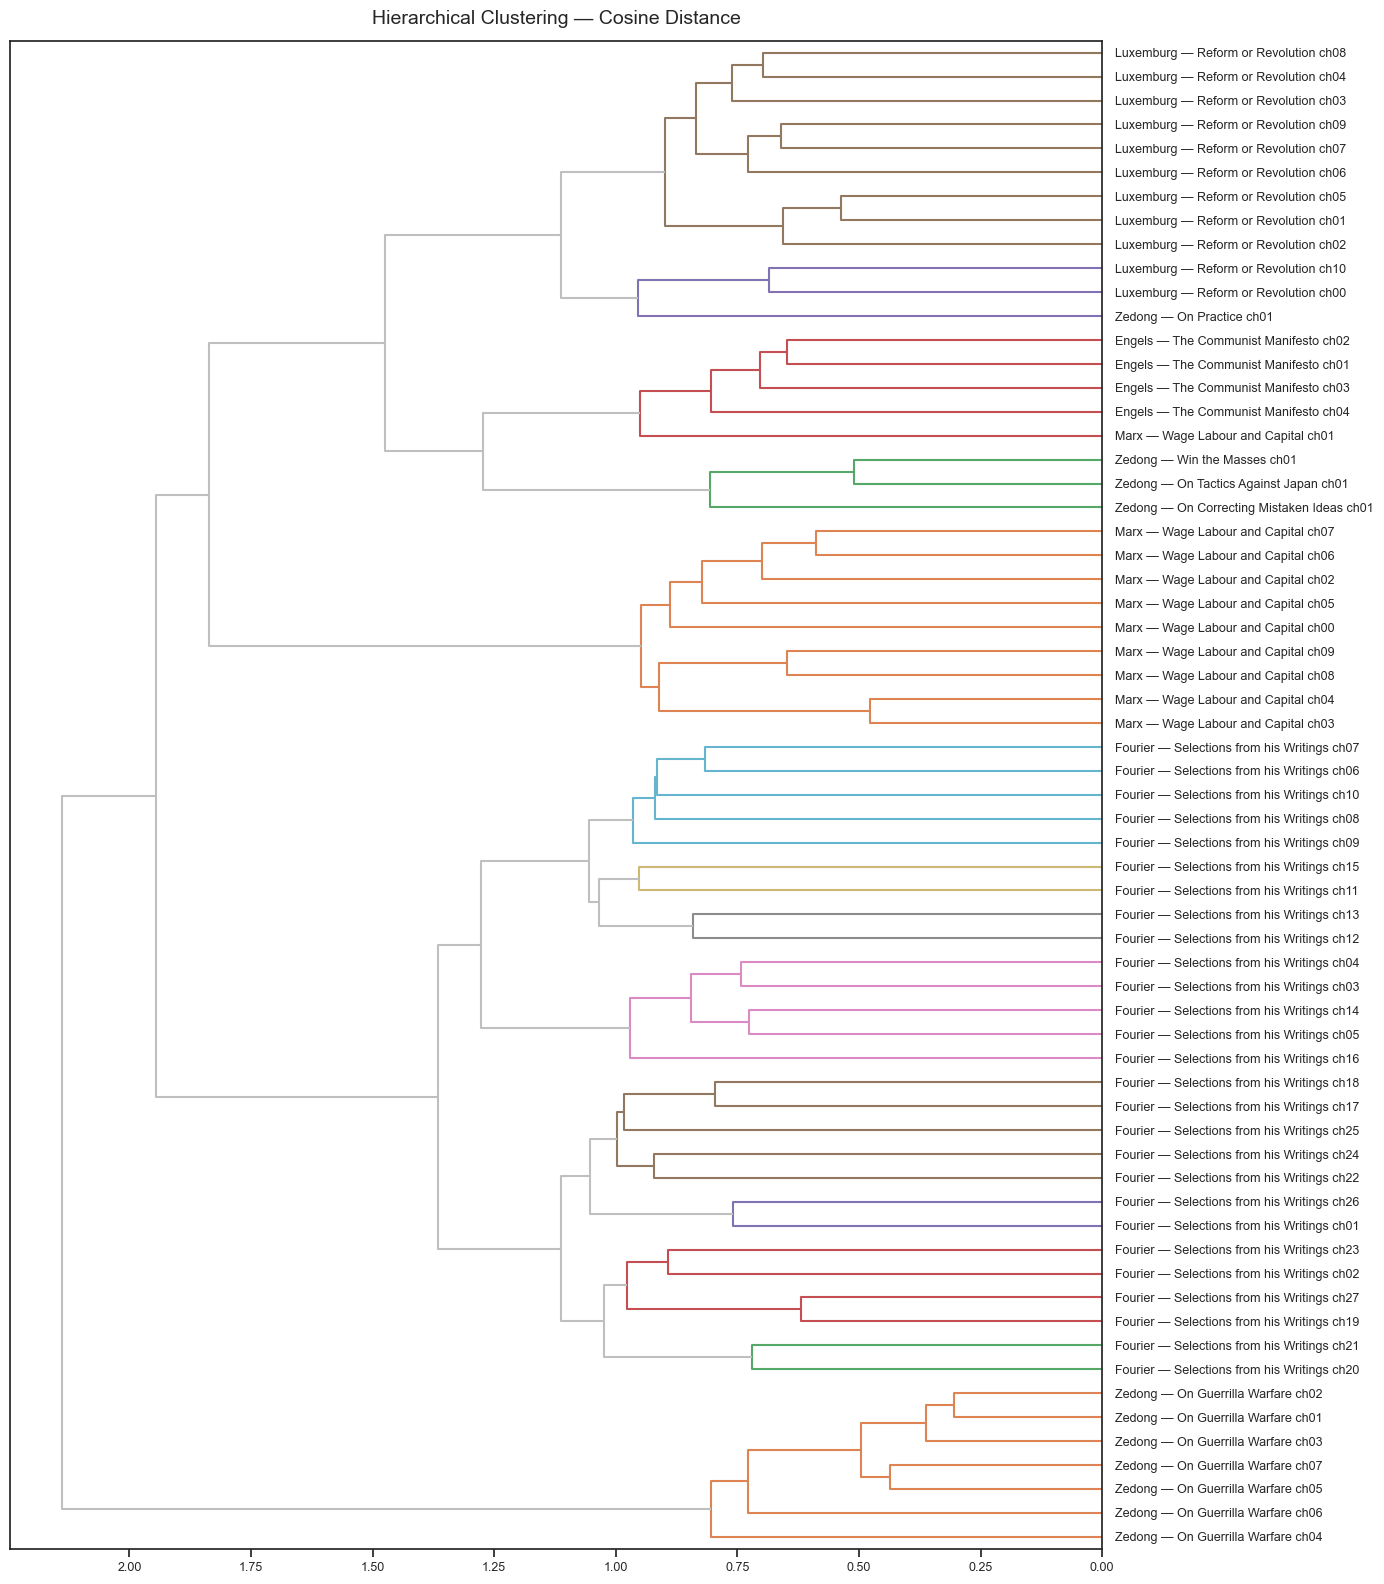

In [11]:
fig = hca(PAIRS.cosine, title='Hierarchical Clustering — Cosine Distance', color_thresh=1)
fig.savefig( 'dendrogram_cosine.png', dpi=150, bbox_inches='tight')
plt.show()

## jaccard distance

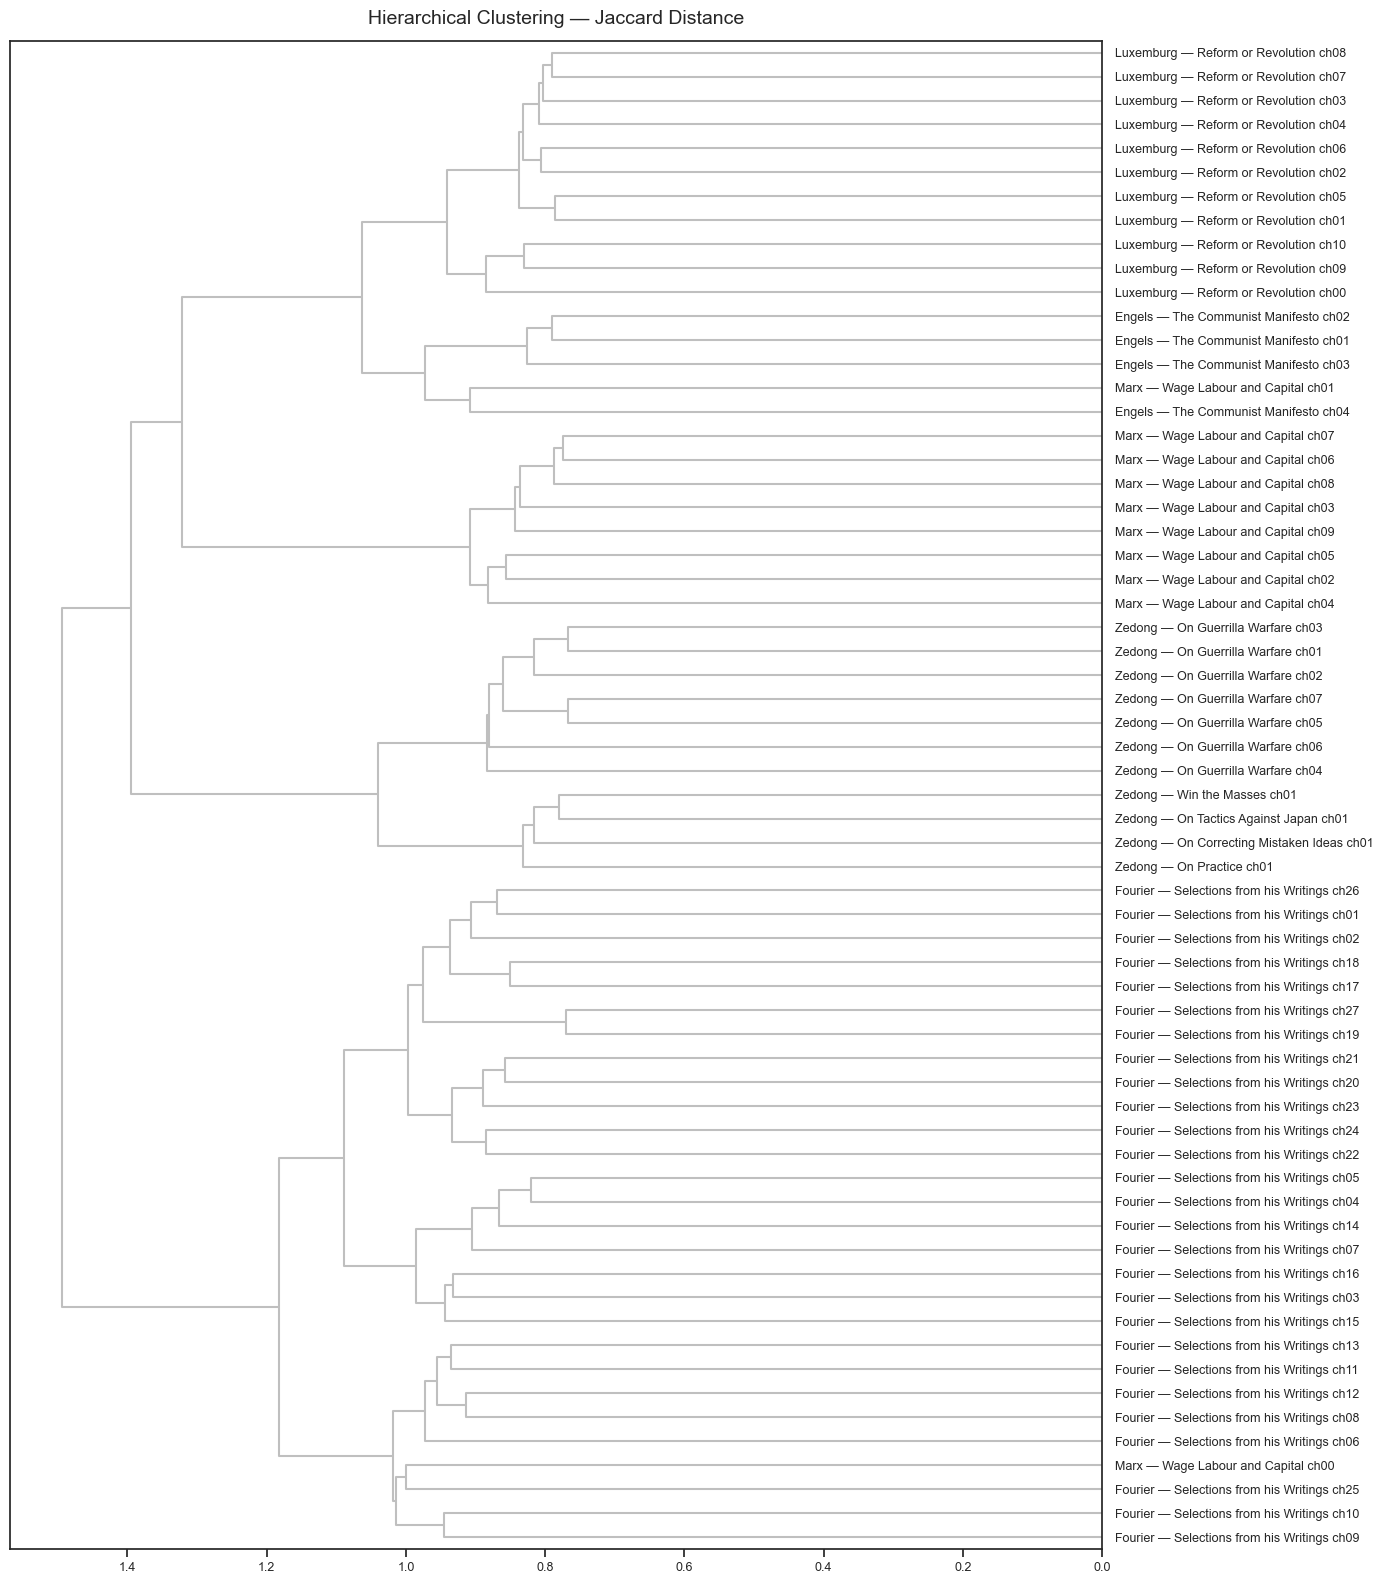

In [12]:
fig = hca(PAIRS.jaccard, title='Hierarchical Clustering — Jaccard Distance', color_thresh=0.6)
fig.savefig('dendrogram_jaccard.png', dpi=150, bbox_inches='tight')
plt.show()